## Завдання 1
Потрібно проаналізувати взаємозв'язок між користувачами, сесіями та виручкою за днями. Усе необхідно запрограмувати в Python з використанням pandas, NumPy і Matplotlib.
Сформуйте таблицю мінімум на 30 днів із колонками "date", "users", "sessions", "revenue".
Розрахуйте кореляційну матрицю для цих метрик.
Побудуйте діаграми розсіювання для пар: users-sessions, users-revenue, sessions-revenue.
Побудуйте лінійний графік "revenue" за датами.
Виведіть матрицю та всі графіки.

Виведення перших рядків таблиці:
        date  users  sessions  revenue
0 2026-01-01    202       224   829.49
1 2026-01-02    448       586  1227.05
2 2026-01-03    370       466  2109.51
3 2026-01-04    206       230   770.33
4 2026-01-05    171       254   809.10

Кореляційна матриця:
             users  sessions   revenue
users     1.000000  0.966602  0.709464
sessions  0.966602  1.000000  0.760502
revenue   0.709464  0.760502  1.000000


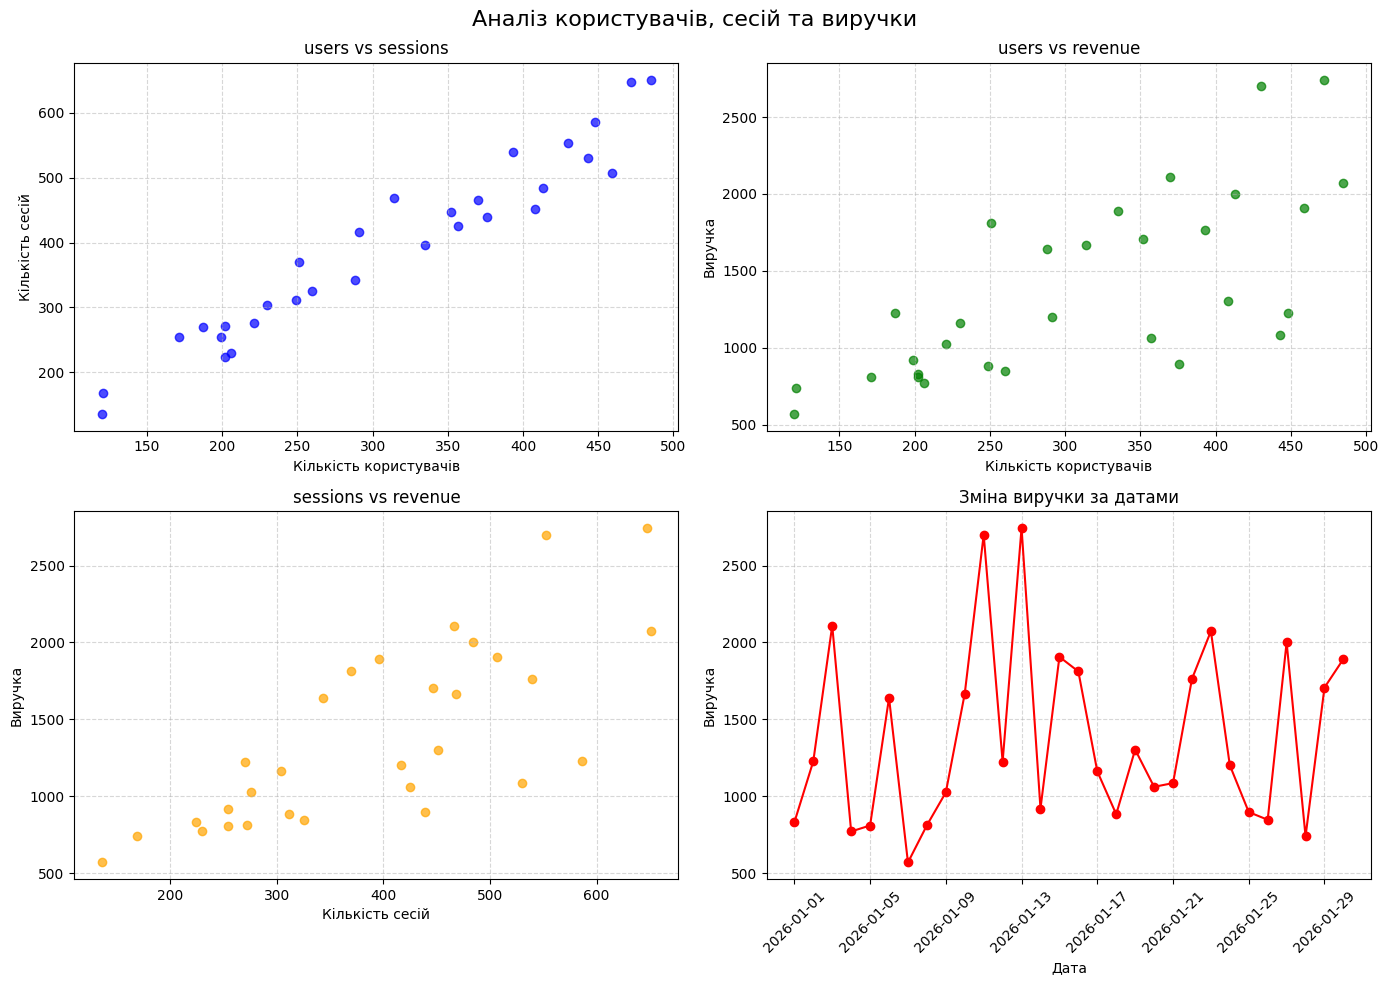

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

dates = pd.date_range(start='2026-01-01', periods=30, freq='D')

np.random.seed(42)
users = np.random.randint(100, 500, size=30)
sessions = (users * np.random.uniform(1.1, 1.5, size=30)).astype(int)
revenue = (sessions * np.random.uniform(2.0, 5.0, size=30)).round(2)

df = pd.DataFrame({
    'date': dates,
    'users': users,
    'sessions': sessions,
    'revenue': revenue
})

print("Виведення перших рядків таблиці:")
print(df.head())

correlation_matrix = df[['users', 'sessions', 'revenue']].corr()
print("\nКореляційна матриця:")
print(correlation_matrix)

fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Аналіз користувачів, сесій та виручки', fontsize=16)

axs[0, 0].scatter(df['users'], df['sessions'], color='blue', alpha=0.7)
axs[0, 0].set_title('users vs sessions')
axs[0, 0].set_xlabel('Кількість користувачів')
axs[0, 0].set_ylabel('Кількість сесій')
axs[0, 0].grid(True, linestyle='--', alpha=0.5)

axs[0, 1].scatter(df['users'], df['revenue'], color='green', alpha=0.7)
axs[0, 1].set_title('users vs revenue')
axs[0, 1].set_xlabel('Кількість користувачів')
axs[0, 1].set_ylabel('Виручка')
axs[0, 1].grid(True, linestyle='--', alpha=0.5)

axs[1, 0].scatter(df['sessions'], df['revenue'], color='orange', alpha=0.7)
axs[1, 0].set_title('sessions vs revenue')
axs[1, 0].set_xlabel('Кількість сесій')
axs[1, 0].set_ylabel('Виручка')
axs[1, 0].grid(True, linestyle='--', alpha=0.5)

axs[1, 1].plot(df['date'], df['revenue'], color='red', marker='o', linestyle='-')
axs[1, 1].set_title('Зміна виручки за датами')
axs[1, 1].set_xlabel('Дата')
axs[1, 1].set_ylabel('Виручка')
axs[1, 1].tick_params(axis='x', rotation=45)
axs[1, 1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Завдання 2
Потрібно проаналізувати дані A/B-експерименту та візуалізувати конверсії. Усе необхідно запрограмувати в Python з використанням pandas, NumPy і Matplotlib.
Сформуйте таблицю з полями "group" (A або B) і "converted" (0/1) з не менш ніж 100 спостереженнями в кожній групі.
Розрахуйте конверсію в групах, абсолютну різницю та відносну зміну.
Побудуйте 95% довірчі інтервали для конверсії в кожній групі.
Побудуйте стовпчасту діаграму конверсій груп із відображенням довірчих інтервалів.
Виведіть усі розраховані значення та графік.

Конверсія групи A: 11.00%
Конверсія групи B: 14.00%
Абсолютна різниця: 3.00%
Відносна зміна: 27.27%
Довірчий інтервал (A): +/- 2.74%
Довірчий інтервал (B): +/- 3.04%


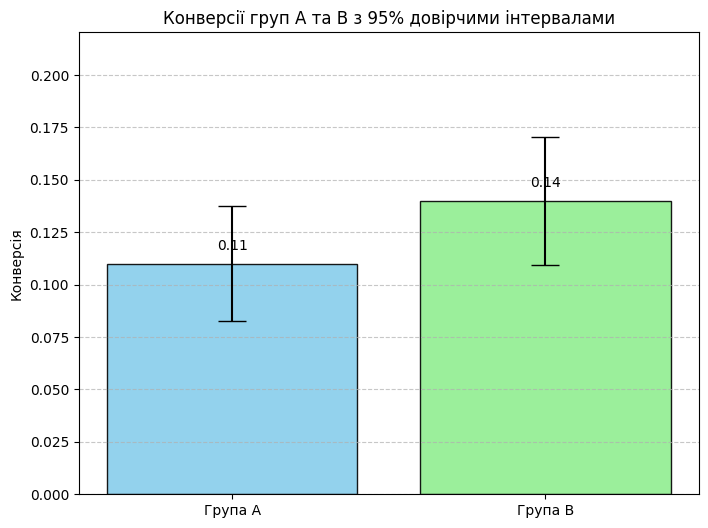

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n_a, n_b = 500, 500
group = ['A'] * n_a + ['B'] * n_b

converted_a = np.random.binomial(n=1, p=0.10, size=n_a)
converted_b = np.random.binomial(n=1, p=0.15, size=n_b)
converted = np.concatenate([converted_a, converted_b])

df_ab = pd.DataFrame({'group': group, 'converted': converted})

conv_a = df_ab[df_ab['group'] == 'A']['converted'].mean()
conv_b = df_ab[df_ab['group'] == 'B']['converted'].mean()

absolute_diff = conv_b - conv_a
relative_change = (conv_b - conv_a) / conv_a * 100

print(f"Конверсія групи A: {conv_a:.2%}")
print(f"Конверсія групи B: {conv_b:.2%}")
print(f"Абсолютна різниця: {absolute_diff:.2%}")
print(f"Відносна зміна: {relative_change:.2f}%")

z_value = 1.96

se_a = np.sqrt(conv_a * (1 - conv_a) / n_a)
ci_a = z_value * se_a

se_b = np.sqrt(conv_b * (1 - conv_b) / n_b)
ci_b = z_value * se_b

print(f"Довірчий інтервал (A): +/- {ci_a:.2%}")
print(f"Довірчий інтервал (B): +/- {ci_b:.2%}")

plt.figure(figsize=(8, 6))
bars = plt.bar(['Група A', 'Група B'], [conv_a, conv_b], yerr=[ci_a, ci_b], 
               capsize=10, color=['skyblue', 'lightgreen'], alpha=0.9, edgecolor='black')

plt.title('Конверсії груп A та B з 95% довірчими інтервалами')
plt.ylabel('Конверсія')
plt.ylim(0, max(conv_a + ci_a, conv_b + ci_b) + 0.05)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, round(yval, 4), ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Завдання 3
Потрібно перевірити дію центральної граничної теореми на прикладі несиметричного розподілу. Усе необхідно запрограмувати в Python з використанням pandas, NumPy і Matplotlib.
Згенеруйте генеральну сукупність щонайменше з 50 000 спостережень із несиметричного розподілу.
Сформуйте кілька підвибірок фіксованого розміру n і для кожної обчисліть середнє.
Збережіть вибіркові середні та побудуйте їхню гістограму.
Повторіть процедуру для щонайменше двох різних n і виведіть обидві гістограми.
Виведіть середнє і стандартне відхилення вибіркових середніх для кожного n.

Генеральна сукупність (Експоненційний розп.):
Середнє = 1.9922, Стандартне відхилення = 1.9934

Аналіз вибіркових середніх за ЦГТ:
Для n=10: Середнє середніх = 1.9653, Стандартне відхилення = 0.6298 (Теор.: 0.6304)
Для n=50: Середнє середніх = 2.0063, Стандартне відхилення = 0.2918 (Теор.: 0.2819)


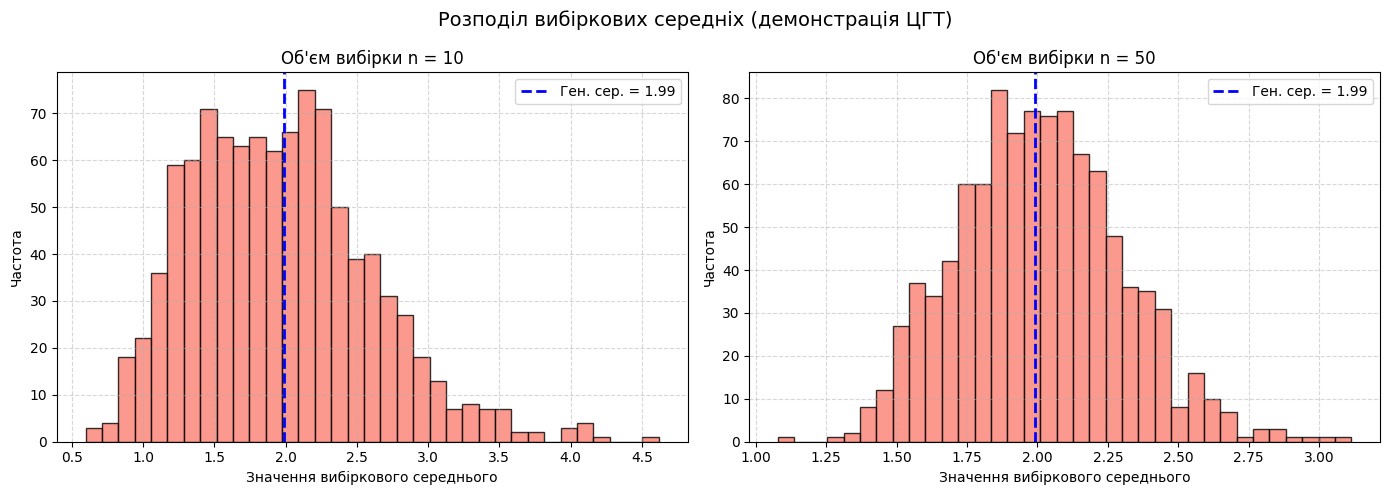

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
population = np.random.exponential(scale=2.0, size=50000)

pop_mean = np.mean(population)
pop_std = np.std(population)
print(f"Генеральна сукупність (Експоненційний розп.):")
print(f"Середнє = {pop_mean:.4f}, Стандартне відхилення = {pop_std:.4f}")

n_values = [10, 50]
num_samples = 1000 
sample_means = {n: [] for n in n_values}

for n in n_values:
    for _ in range(num_samples):
        sample = np.random.choice(population, size=n, replace=True)
        sample_means[n].append(np.mean(sample))

print("\nАналіз вибіркових середніх за ЦГТ:")
for n in n_values:
    mean_val = np.mean(sample_means[n])
    std_val = np.std(sample_means[n])
    print(f"Для n={n:2}: Середнє середніх = {mean_val:.4f}, Стандартне відхилення = {std_val:.4f} (Теор.: {pop_std/np.sqrt(n):.4f})")

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Розподіл вибіркових середніх (демонстрація ЦГТ)', fontsize=14)

for i, n in enumerate(n_values):
    axs[i].hist(sample_means[n], bins=35, color='salmon', edgecolor='black', alpha=0.8)
    axs[i].axvline(pop_mean, color='blue', linestyle='dashed', linewidth=2, label=f'Ген. сер. = {pop_mean:.2f}')
    axs[i].set_title(f'Об\'єм вибірки n = {n}')
    axs[i].set_xlabel('Значення вибіркового середнього')
    axs[i].set_ylabel('Частота')
    axs[i].legend()
    axs[i].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Завдання 4
Потрібно проаналізувати часовий ряд продажів і візуалізувати ковзаючі метрики. Усе необхідно запрограмувати в Python з використанням pandas, NumPy і Matplotlib.
Сформуйте таблицю "date" і "sales" за 90 днів.
Додайте ковзне середнє і ковзне стандартне відхилення за обраним вікном.
Побудуйте графік вихідних продажів і графік ковзного середнього на одному полі.
Побудуйте окремий графік ковзного стандартного відхилення.
Виведіть таблицю з першими рядками нових стовпців і обидва графіки.

Перші рядки з новими стовпцями (вікно=7):
        date       sales  rolling_mean  rolling_std
0 2026-01-01  109.934283           NaN          NaN
1 2026-01-02   98.358309           NaN          NaN
2 2026-01-03  115.200962           NaN          NaN
3 2026-01-04  133.831384           NaN          NaN
4 2026-01-05   99.811315           NaN          NaN
5 2026-01-06  100.935238           NaN          NaN
6 2026-01-07  138.325829    113.771046    16.428149
7 2026-01-08  123.213863    115.668129    16.676121
8 2026-01-09   99.599276    115.845410    16.466715
9 2026-01-10  120.963560    116.668638    16.572831


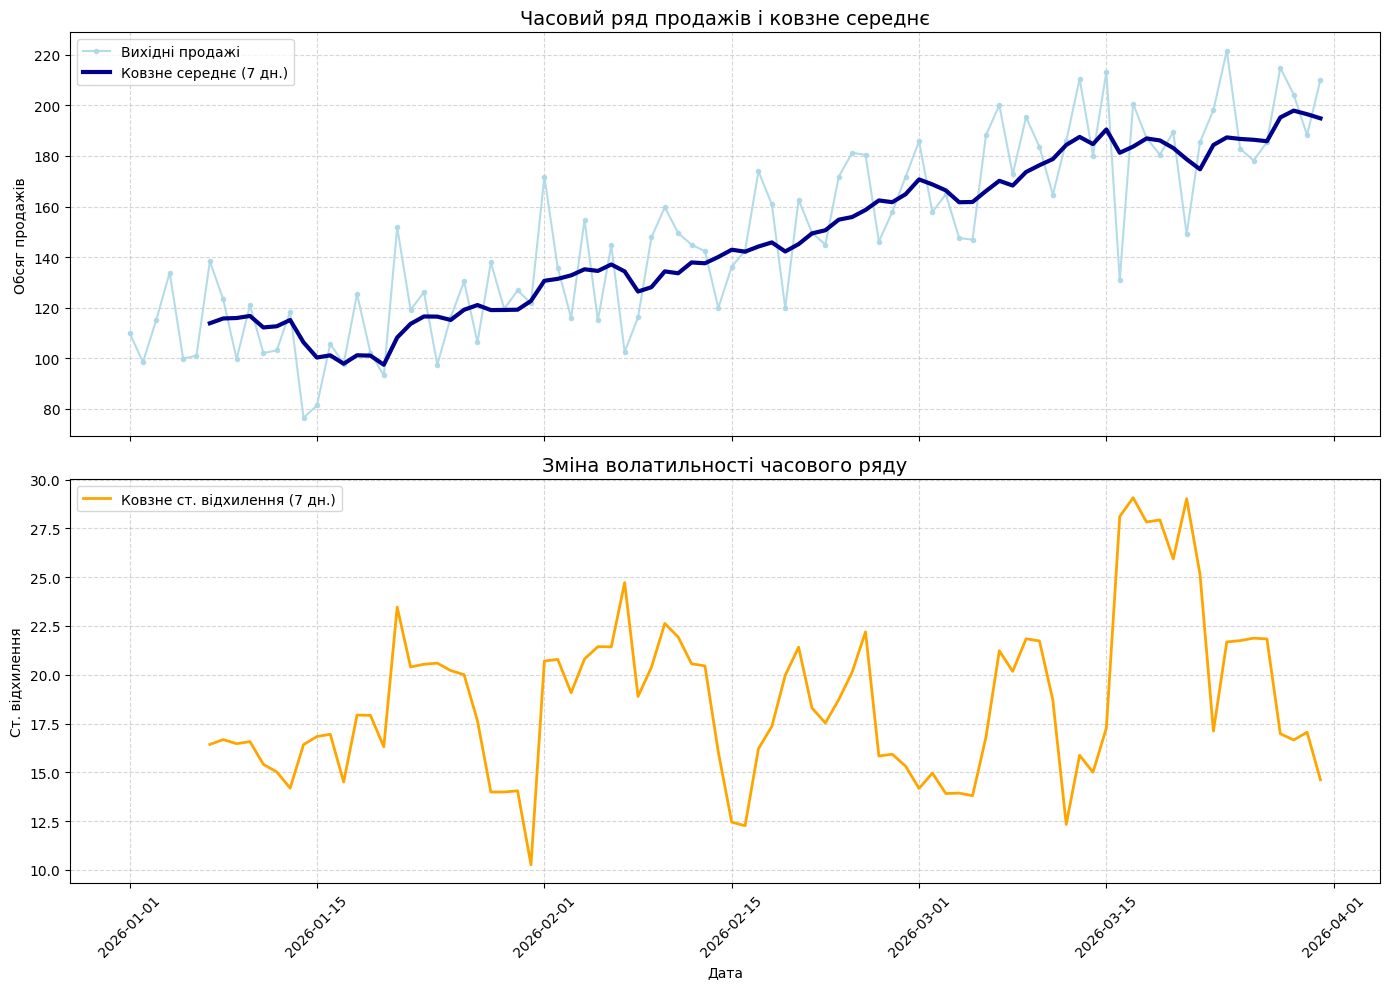

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

dates = pd.date_range(start='2026-01-01', periods=90, freq='D')
np.random.seed(42)

trend = np.linspace(100, 200, 90)
noise = np.random.normal(0, 20, 90)
sales = trend + noise

df_ts = pd.DataFrame({'date': dates, 'sales': sales})

window_size = 7
df_ts['rolling_mean'] = df_ts['sales'].rolling(window=window_size).mean()
df_ts['rolling_std'] = df_ts['sales'].rolling(window=window_size).std()

print(f"Перші рядки з новими стовпцями (вікно={window_size}):")
print(df_ts.head(10))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

ax1.plot(df_ts['date'], df_ts['sales'], label='Вихідні продажі', color='lightblue', marker='.', alpha=0.9)
ax1.plot(df_ts['date'], df_ts['rolling_mean'], label=f'Ковзне середнє ({window_size} дн.)', color='darkblue', linewidth=3)
ax1.set_title('Часовий ряд продажів і ковзне середнє', fontsize=14)
ax1.set_ylabel('Обсяг продажів')
ax1.legend(loc='upper left')
ax1.grid(True, linestyle='--', alpha=0.5)

ax2.plot(df_ts['date'], df_ts['rolling_std'], label=f'Ковзне ст. відхилення ({window_size} дн.)', color='orange', linewidth=2)
ax2.set_title('Зміна волатильності часового ряду', fontsize=14)
ax2.set_xlabel('Дата')
ax2.set_ylabel('Ст. відхилення')
ax2.legend(loc='upper left')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()